In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
import bambi as bmb
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
pa_gs = pd.read_csv('data/pa_data.csv')
temps = pd.read_csv("data/pa_temps_supplement.csv")
pa_gs = pa_gs.merge(temps, on=["station_id", "year"], how="left")

pa_gs = pa_gs[pa_gs['year'] >= 1960]
pa_gs = pa_gs.drop(['station_id', 'last_spring_frost_date', 'first_fall_frost_date', 'station_name','state'], axis=1)

In [13]:
pa_gs.std()

year                     18.939657
last_spring_frost_doy    17.812325
first_fall_frost_doy     17.608496
growing_season_length    31.049466
dtr_annual                1.408353
                           ...    
evaporation_station       0.183454
tmean_spring              2.004611
tmean_april               2.185304
tmean_fall                1.827523
tmean_october             2.191691
Length: 66, dtype: float64

In [8]:
def bayesian_model_standardized(data, target_var_name, cov_names):

    sc = StandardScaler()
    data_standardized = sc.fit_transform(data)
    data_standardized = pd.DataFrame(data_standardized)
    data_standardized.columns = data.columns

    std = data.std()
    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_names} + year",
                      f"sigma ~ {cov_names} + year")
    model = bmb.Model(formula, data=data_standardized, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = pa_gs['growing_season_length'] - model.predict(output, inplace=False).posterior["mu"].mean().values

    model_r2_score = model.r2_score(output)
    
    return model, output, std, resid, model_r2_score

def bayesian_model_unstandardized(data, target_var_name, cov_names):

    formula = bmb.Formula(f"{target_var_name} ~ {cov_names} + year",
                      f"sigma ~ {cov_names} + year")
    model = bmb.Model(formula, data=data, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = data[target_var_name] - model.predict(output, inplace=False).posterior["mu"].mean().values

    model_r2_score = model.r2_score(output)
    
    return model, output, resid, model_r2_score

### 7/7 Work

In [179]:
sc = StandardScaler()
pa_gs_standardized = sc.fit_transform(pa_gs)
pa_gs_standardized = pd.DataFrame(pa_gs_standardized)
pa_gs_standardized.columns = pa_gs.columns

formula_yr_only = bmb.Formula("growing_season_length ~ year",
                      f"sigma ~ year")
model_yr_only = bmb.Model(formula_yr_only, data= pa_gs_standardized)
output_yr_only = model_yr_only.fit(idata_kwargs={'log_likelihood':True})
r2_yr_only = model_yr_only.r2_score(output_yr_only)

az.summary(output_yr_only)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.881       3           2928.24 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           1.281       3           2801.53 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.869       3           2730.77 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.851       3           2925.83 draws/s      0:00:00    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-0.0017,0.0126,-0.022,0.018,6082,3718,1.00,0.00016,0.00012
year,0.2628,0.012,0.24,0.28,5698,3180,1.00,0.00016,0.00011
sigma_Intercept,-0.0444,0.0089,-0.059,-0.03,6348,3080,1.00,0.00011,7.8e-05
sigma_year,-0.1168,0.009,-0.13,-0.1,6105,3164,1.00,0.00012,8.5e-05
mu[0],0.2744,0.0156,0.25,0.3,7875,3112,1.00,0.00018,0.00012
...,...,...,...,...,...,...,...,...,...
sigma[6408],0.7956,0.0133,0.77,0.82,6191,3393,1.00,0.00017,0.00012
sigma[6409],0.7907,0.0136,0.77,0.81,6186,3353,1.00,0.00017,0.00013
sigma[6410],0.7858,0.0138,0.76,0.81,6177,3239,1.00,0.00018,0.00013
sigma[6411],0.781,0.014,0.76,0.8,6180,3350,1.00,0.00018,0.00013


In [140]:
print(r2_yr_only)

residual_R2(mean=0.069, eti_lb=0.06, eti_ub=0.078)


In [148]:
dtr_yr_standardized_model, dtr_yr_standardized_output, std_dtr_yr_standardized, resid_dtr_yr_standardized, r2_dtr_yr_standardized = bayesian_model_standardized(pa_gs, 'growing_season_length', 'dtr_annual')
az.summary(dtr_yr_output)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.871       7           1928.57 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.984       3           2089.32 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.704       3           2053.92 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.895       3           2041.83 draws/s      0:00:00    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-0.0027,0.0103,-0.02,0.014,4926,3333,1.00,0.00015,0.0001
dtr_annual,-0.49,0.0108,-0.51,-0.47,4903,3337,1.00,0.00015,0.00011
year,0.1823,0.0103,0.17,0.2,4263,3360,1.00,0.00016,0.00011
sigma_Intercept,-0.2013,0.0088,-0.22,-0.19,5060,3437,1.00,0.00012,8.7e-05
sigma_dtr_annual,-0.0598,0.008,-0.072,-0.047,4114,3467,1.00,0.00012,9e-05
sigma_year,-0.1098,0.0094,-0.12,-0.095,4511,2940,1.00,0.00014,0.0001


In [45]:
dtr_yr_temp_unstandardized_model, dtr_yr_temp_unstandardized_output, std_dtr_temp_yr_standardized, resid_dtr_yr_temp_unstandardized, r2_dtr_yr_temp_unstandardized = bayesian_model_standardized(pa_gs, 'growing_season_length', 'dtr_annual + tmean_fall + tmean_spring')

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.455       7           1206.11 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.540       7           1274.12 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.606       7           1211.13 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.659       7           1216.03 draws/s      0:00:01    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


In [48]:
az.summary(dtr_yr_temp_unstandardized_output).head(10)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.0013,0.0073,-0.01,0.013,7223,2924,1.00,8.6e-05,6.3e-05
dtr_annual,-0.3533,0.0078,-0.37,-0.34,6743,3260,1.00,9.5e-05,6.7e-05
tmean_fall,0.4324,0.0105,0.42,0.45,4176,3379,1.00,0.00016,0.00011
tmean_spring,0.2316,0.0102,0.22,0.25,4472,3512,1.00,0.00015,0.00011
year,0.0723,0.0072,0.061,0.084,6629,3346,1.00,8.8e-05,6.1e-05
sigma_Intercept,-0.5579,0.0088,-0.57,-0.54,7685,3284,1.00,0.0001,6.9e-05
sigma_dtr_annual,0.044,0.009,0.03,0.058,6599,2863,1.00,0.00011,7.8e-05
sigma_tmean_fall,0.0012,0.0123,-0.018,0.021,4292,3219,1.00,0.00019,0.00014
sigma_tmean_spring,-0.0464,0.0123,-0.066,-0.027,4468,2934,1.00,0.00018,0.00013
sigma_year,-0.0895,0.0094,-0.11,-0.075,6057,3130,1.00,0.00012,8.4e-05


In [149]:
print(r2_dtr_yr_standardized)

residual_R2(mean=0.31, eti_lb=0.29, eti_ub=0.32)


In [150]:
print(std_values)

dtr_annual                1.408353
growing_season_length    31.049466
year                     18.939657
dtype: float64


In [151]:
dtr_yr_unstandardized_model, dtr_yr_unstandardized_output, dtr_yr_resid, dtr_yr_r2 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', 'dtr_annual')
az.summary(dtr_yr_unstandardized_output)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.713       3           890.96 draws/s       0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.896       7           783.38 draws/s       0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.899       3           844.46 draws/s       0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.682       3           1035.82 draws/s      0:00:01    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-307,34.5,-360,-250,3903,2753,1.00,0.55,0.39
dtr_annual,-10.794,0.23,-11,-10,4950,3383,1.00,0.0033,0.0023
year,0.2992,0.017,0.27,0.33,4030,2826,1.00,0.00027,0.00019
sigma_Intercept,15.28,1.01,14,17,4296,3489,1.00,0.015,0.011
sigma_dtr_annual,-0.0426,0.0059,-0.052,-0.033,4888,3378,1.00,8.4e-05,5.8e-05
...,...,...,...,...,...,...,...,...,...
sigma[6408],22.8,0.416,22,23,5677,3608,1.00,0.0055,0.0041
sigma[6409],22.34,0.404,22,23,5385,3668,1.00,0.0055,0.0041
sigma[6410],22.27,0.413,22,23,5397,3650,1.00,0.0056,0.0042
sigma[6411],21.99,0.413,21,23,5232,3683,1.00,0.0057,0.0043


In [152]:
print(dtr_yr_r2)

residual_R2(mean=0.31, eti_lb=0.29, eti_ub=0.32)


In [180]:
cov_set_1= 'dtr_annual + tmean_spring + tmean_fall'
cov_set_1_unstandardized_model, cov_set_1_unstandardized_output, resid_set_1, r2_set_1  = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_1)
az.summary(cov_set_1_unstandardized_output)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.620       7           674.37 draws/s       0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.498       7           848.58 draws/s       0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.550       7           705.17 draws/s       0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.546       7           947.76 draws/s       0:00:02    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-97.9,24.8,-140,-58,6055,3142,1.00,0.32,0.22
dtr_annual,-7.789,0.171,-8.1,-7.5,6532,2926,1.00,0.0021,0.0015
tmean_spring,3.589,0.157,3.3,3.8,4850,3639,1.00,0.0023,0.0016
tmean_fall,7.34,0.176,7.1,7.6,4694,3363,1.00,0.0026,0.0017
year,0.1184,0.0124,0.099,0.14,6210,3064,1.00,0.00016,0.00011
...,...,...,...,...,...,...,...,...,...
sigma[6399],14.152,0.251,14,15,5962,3587,1.00,0.0033,0.0023
sigma[6400],14.236,0.262,14,15,6375,3445,1.00,0.0033,0.0024
sigma[6401],14.304,0.272,14,15,5562,3345,1.00,0.0036,0.0026
sigma[6402],13.269,0.311,13,14,5299,3692,1.00,0.0043,0.0029


In [154]:
cov_set_2 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude'

In [155]:
cov_set_2_unstandardized_model, cov_set_2_unstandardized_output, resid_set_2, r2_set_2 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_2)
az.summary(cov_set_2_unstandardized_output)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.500       7           668.87 draws/s       0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.674       7           470.56 draws/s       0:00:04    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.463       7           535.90 draws/s       0:00:03    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.495       7           381.20 draws/s       0:00:05    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,89,30,40,140,6703,3454,1.00,0.36,0.26
dtr_annual,-7.77,0.172,-8,-7.5,5885,3358,1.00,0.0022,0.0016
tmean_spring,3.028,0.171,2.8,3.3,3998,3252,1.00,0.0027,0.0019
tmean_fall,6.851,0.185,6.6,7.2,4363,3040,1.00,0.0028,0.002
latitude,-2.56,0.457,-3.3,-1.8,4290,3183,1.00,0.007,0.0049
...,...,...,...,...,...,...,...,...,...
sigma[6399],14.537,0.336,14,15,6080,3232,1.00,0.0043,0.0031
sigma[6400],14.635,0.337,14,15,6444,3525,1.00,0.0042,0.003
sigma[6401],14.711,0.348,14,15,5685,3359,1.00,0.0046,0.0033
sigma[6402],13.74,0.44,13,14,5351,3523,1.00,0.006,0.0043


In [156]:
cov_set_3 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual'
cov_set_3_unstandardized_model, cov_set_3_unstandardized_output, resid_set_3, r2_set_3 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_3)
az.summary(cov_set_3_unstandardized_output)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.338       31          390.60 draws/s       0:00:05    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.336       15          423.65 draws/s       0:00:04    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.383       15          363.14 draws/s       0:00:05    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.274       15          384.10 draws/s       0:00:05    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,95.4,29.1,49,140,6611,2993,1.00,0.36,0.25
dtr_annual,-9.25,0.258,-9.7,-8.8,2336,2560,1.00,0.0053,0.0039
tmean_spring,1.807,0.236,1.4,2.2,3561,2939,1.00,0.004,0.0027
tmean_fall,5.389,0.263,5,5.8,3216,3024,1.00,0.0046,0.0034
latitude,-1.66,0.459,-2.4,-0.93,6237,2896,1.00,0.0058,0.0044
...,...,...,...,...,...,...,...,...,...
sigma[6399],14.683,0.346,14,15,5786,3656,1.00,0.0046,0.0033
sigma[6400],14.944,0.358,14,16,6597,3357,1.00,0.0044,0.0031
sigma[6401],14.58,0.385,14,15,4246,3380,1.00,0.006,0.0044
sigma[6402],13.88,0.443,13,15,5703,3273,1.00,0.0059,0.0042


In [157]:
cov_set_4 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual'
cov_set_4_unstandardized_model, cov_set_4_unstandardized_output, resid_set_4, r2_set_4 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_4)
az.summary(cov_set_4_unstandardized_output)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.270       15          238.37 draws/s       0:00:08    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.309       15          320.39 draws/s       0:00:06    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.378       31          300.46 draws/s       0:00:06    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.222       15          307.36 draws/s       0:00:06    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,99,29.7,51,150,7154,2803,1.00,0.35,0.25
dtr_annual,-9.405,0.255,-9.8,-9,2771,3132,1.00,0.0048,0.0034
tmean_spring,1.558,0.243,1.2,1.9,4029,3256,1.00,0.0038,0.0027
tmean_fall,5.357,0.26,4.9,5.8,3454,3105,1.00,0.0044,0.0031
latitude,-1.95,0.46,-2.7,-1.2,6327,2821,1.00,0.0058,0.0042
...,...,...,...,...,...,...,...,...,...
sigma[6399],14.034,0.394,13,15,7126,3462,1.00,0.0047,0.0033
sigma[6400],15.157,0.433,14,16,7725,3378,1.00,0.0049,0.0035
sigma[6401],13.82,0.462,13,15,5249,3407,1.00,0.0064,0.0046
sigma[6402],13.93,0.445,13,15,6697,3822,1.00,0.0054,0.0039


In [158]:
cov_set_5 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual'
cov_set_5_unstandardized_model, cov_set_5_unstandardized_output, resid_set_5, r2_set_5 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_5)
az.summary(cov_set_5_unstandardized_output)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.311       15          291.79 draws/s       0:00:06    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.309       15          198.26 draws/s       0:00:10    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.236       15          213.97 draws/s       0:00:09    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.288       15          220.40 draws/s       0:00:09    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,228,40.4,160,290,4053,3744,1.00,0.64,0.45
dtr_annual,-9.61,0.257,-10,-9.2,2372,2860,1.00,0.0053,0.0037
tmean_spring,1.506,0.241,1.1,1.9,3197,2780,1.00,0.0043,0.0029
tmean_fall,5.075,0.265,4.6,5.5,3186,3401,1.00,0.0047,0.0033
latitude,-1.85,0.475,-2.6,-1.1,7550,3085,1.00,0.0055,0.0038
...,...,...,...,...,...,...,...,...,...
sigma[6243],14.06,0.395,13,15,4358,3537,1.00,0.006,0.0043
sigma[6244],15.3,0.404,15,16,4898,3475,1.00,0.0058,0.0043
sigma[6245],13.25,0.402,13,14,5194,3517,1.00,0.0056,0.004
sigma[6246],15.61,0.49,15,16,4712,3565,1.00,0.0071,0.0051


In [159]:
cov_set_6 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic'
cov_set_6_unstandardized_model, cov_set_6_unstandardized_output, resid_set_6, r2_set_6 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_6)
az.summary(cov_set_6_unstandardized_output)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.151       31          163.25 draws/s       0:00:12    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.219       31          188.48 draws/s       0:00:10    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.177       31          248.16 draws/s       0:00:08    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.142       31          195.11 draws/s       0:00:10    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,247,42.9,180,310,5241,3397,1.00,0.59,0.41
dtr_annual,-9.653,0.254,-10,-9.2,3293,3108,1.00,0.0044,0.0031
tmean_spring,1.429,0.244,1,1.8,3462,2918,1.00,0.0041,0.0029
tmean_fall,5.109,0.263,4.7,5.5,3368,2739,1.00,0.0045,0.0033
latitude,-1.8,0.457,-2.5,-1.1,6245,3393,1.00,0.0058,0.004
...,...,...,...,...,...,...,...,...,...
sigma[6243],14.06,0.404,13,15,5542,3273,1.00,0.0054,0.0039
sigma[6244],15.39,0.426,15,16,5006,3764,1.00,0.006,0.0042
sigma[6245],13.35,0.417,13,14,5374,3535,1.00,0.0057,0.0041
sigma[6246],15.69,0.502,15,17,5296,3939,1.00,0.0069,0.0048


In [160]:
cov_set_7 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + dewpoint_station'
cov_set_7_unstandardized_model, cov_set_7_unstandardized_output, resid_set_7, r2_set_7 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_7)
az.summary(cov_set_7_unstandardized_output)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.196       31          137.53 draws/s       0:00:14    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.215       31          184.86 draws/s       0:00:10    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.163       31          177.57 draws/s       0:00:11    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.174       31          169.91 draws/s       0:00:11    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,270,43.9,200,340,4477,3459,1.00,0.66,0.48
dtr_annual,-9.85,0.282,-10,-9.4,2509,2663,1.00,0.0056,0.004
tmean_spring,1.472,0.252,1.1,1.9,3483,3218,1.00,0.0043,0.003
tmean_fall,5.415,0.271,5,5.8,3885,3279,1.00,0.0043,0.0031
latitude,-3.26,0.509,-4.1,-2.4,6781,3186,1.00,0.0062,0.0044
...,...,...,...,...,...,...,...,...,...
sigma[6243],14.17,0.431,14,15,5272,3289,1.00,0.006,0.0041
sigma[6244],15.43,0.428,15,16,5163,3846,1.00,0.0059,0.0042
sigma[6245],13.48,0.426,13,14,5031,3443,1.00,0.006,0.0041
sigma[6246],15.78,0.512,15,17,5476,3576,1.00,0.0069,0.0049


In [9]:
cov_set_8 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + dewpoint_station + soil_moisture_station + cloud_cover_station + evaporation_station'
cov_set_8_unstandardized_model, cov_set_8_unstandardized_output, resid_set_8, r2_set_8 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_8)
az.summary(cov_set_8_unstandardized_output).head(36)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.135       31          139.69 draws/s       0:00:14    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.165       31          149.28 draws/s       0:00:13    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.142       31          131.76 draws/s       0:00:15    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.166       31          179.34 draws/s       0:00:11    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,119,51,38,200,4262,3806,1.00,0.78,0.54
dtr_annual,-9.921,0.282,-10,-9.5,3268,3058,1.00,0.0049,0.0035
tmean_spring,1.253,0.248,0.86,1.6,3951,3258,1.00,0.0039,0.0029
tmean_fall,5.357,0.266,4.9,5.8,4081,3237,1.00,0.0042,0.0031
latitude,-2.47,0.57,-3.4,-1.5,5704,3608,1.00,0.0076,0.0054
longitude,1.194,0.196,0.89,1.5,4557,3515,1.00,0.0029,0.002
tmax_annual,4.04,0.45,3.3,4.8,3061,2837,1.00,0.0082,0.0058
oni_annual,-1.023,0.37,-1.6,-0.43,6610,3197,1.00,0.0046,0.0032
nao_annual,0.69,0.72,-0.46,1.9,6396,3235,1.00,0.0091,0.0064
pna_annual,1.65,0.8,0.39,2.9,6950,3735,1.00,0.0096,0.0071


In [166]:
print(f'Year Only R Squared Score (0 covariates): {r2_yr_only}')
print(f'Year and DTR only R Squared Score (1 covariate): {dtr_yr_r2}')
print(f'Covariate Set 1 R Squared Score (3 covariates): {r2_set_1}')
print(f'Covariate Set 2 R Squared Score (5 covariates): {r2_set_2}')
print(f'Covariate Set 3 R Squared Score (6 covariates): {r2_set_3}')
print(f'Covariate Set 4 R Squared Score (8 covariates): {r2_set_4}')
print(f'Covariate Set 5 R Squared Score (10 covariates): {r2_set_5}')
print(f'Covariate Set 6 R Squared Score (11 covariates): {r2_set_6}')
print(f'Covariate Set 7 R Squared Score (13 covariates): {r2_set_7}')
print(f'Covariate Set 8 R Squared Score (16 covariates): {r2_set_8}')

Year Only R Squared Score (0 covariates): residual_R2(mean=0.069, eti_lb=0.06, eti_ub=0.078)
Year and DTR only R Squared Score (1 covariate): residual_R2(mean=0.31, eti_lb=0.29, eti_ub=0.32)
Covariate Set 1 R Squared Score (3 covariates): residual_R2(mean=0.66, eti_lb=0.65, eti_ub=0.67)
Covariate Set 2 R Squared Score (5 covariates): residual_R2(mean=0.67, eti_lb=0.66, eti_ub=0.67)
Covariate Set 3 R Squared Score (6 covariates): residual_R2(mean=0.67, eti_lb=0.67, eti_ub=0.68)
Covariate Set 4 R Squared Score (8 covariates): residual_R2(mean=0.67, eti_lb=0.67, eti_ub=0.68)
Covariate Set 5 R Squared Score (10 covariates): residual_R2(mean=0.67, eti_lb=0.67, eti_ub=0.68)
Covariate Set 6 R Squared Score (11 covariates): residual_R2(mean=0.67, eti_lb=0.67, eti_ub=0.68)
Covariate Set 7 R Squared Score (13 covariates): residual_R2(mean=0.68, eti_lb=0.67, eti_ub=0.68)
Covariate Set 8 R Squared Score (16 covariates): residual_R2(mean=0.68, eti_lb=0.67, eti_ub=0.68)


In [164]:
az.compare({"model5": cov_set_5_unstandardized_output, "model6": cov_set_6_unstandardized_output,
            "model7": cov_set_7_unstandardized_output, "model8": cov_set_8_unstandardized_output})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
model8,0,0.0,0.0,NaN,,,48.9,-26700.0,77.0,0.80
model7,1,-20.0,8.4,0.99,,,40.5,-26700.0,76.0,0.05
model6,2,-50.0,12.0,1.00,,,35.3,-26700.0,76.0,0.00
model5,3,-50.0,12.0,1.00,,,33.7,-26700.0,76.0,0.15


In [170]:
az.compare({"model1": cov_set_1_unstandardized_output, "model2": cov_set_2_unstandardized_output, 
            "model3": cov_set_3_unstandardized_output, "model4": cov_set_4_unstandardized_output})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
model4,0,0.0,0.0,NaN,,,27.7,-27400.0,78.0,0.84
model3,1,-20.0,7.8,1.0,,,22.5,-27400.0,78.0,0.03
model2,2,-50.0,12.0,1.0,,,19.3,-27400.0,77.0,0.06
model1,3,-140.0,19.0,1.0,,,14.3,-27500.0,77.0,0.07


In [171]:
az.compare({"yr_only_model": output_yr_only, "yr_dtr_only_model": dtr_yr_unstandardized_output})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
yr_only_model,0,0.0,0.0,NaN,,,4.8,-8800.0,69.0,1.0
yr_dtr_only_model,1,-21030.0,42.0,1.0,,,8.0,-29800.0,68.0,0.0


* No Models have ELPD > 0 (and not particularly close, either)
* Models Ranked by ELPD value:
    * Year Only Model
    * 16 covariates
    * 13 coviariates
    * 11 covariates
    * 10 covariates
    * 8 covariates
    * 6 covariates
    * 5 covariates
    * 3 covariates
    * Year and DTR only model

In [198]:
cov_set_9 = 'dtr_annual + tmean_fall + latitude + longitude + tmax_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + soil_moisture_station + cloud_cover_station + evaporation_station'
cov_set_9_unstandardized_model, cov_set_9_unstandardized_output, resid_set_9, r2_set_9 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_9)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.212       31          174.15 draws/s       0:00:11    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.223       31          202.23 draws/s       0:00:09    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.146       15          194.04 draws/s       0:00:10    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.203       31          170.44 draws/s       0:00:11    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.


In [200]:
az.summary(cov_set_9_unstandardized_output).head(30)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,161,47,84,240,4300,3451,1.00,0.72,0.52
dtr_annual,-10.248,0.222,-11,-9.9,3338,2808,1.00,0.0038,0.0027
tmean_fall,5.144,0.259,4.7,5.6,3305,2953,1.00,0.0045,0.0031
latitude,-2.67,0.58,-3.6,-1.7,3905,3102,1.00,0.0092,0.0065
longitude,1.343,0.187,1,1.6,3915,3280,1.00,0.003,0.0022
tmax_annual,4.79,0.306,4.3,5.3,3169,2983,1.00,0.0054,0.0038
pna_annual,1.49,0.77,0.28,2.7,5271,3333,1.00,0.011,0.0073
amo_annual,12.2,3.54,6.5,18,3160,2903,1.00,0.063,0.044
sst_north_atlantic,-9.8,2.98,-15,-5,3031,2694,1.00,0.054,0.038
pwat_station,-2.031,0.262,-2.4,-1.6,3852,3232,1.00,0.0042,0.003


In [201]:
print(r2_set_9)

residual_R2(mean=0.68, eti_lb=0.67, eti_ub=0.68)


In [202]:
cov_set_10 = 'dtr_annual + tmean_fall + tmax_annual + amo_annual + sst_north_atlantic + pwat_station + soil_moisture_station + cloud_cover_station + evaporation_station'
cov_set_10_unstandardized_model, cov_set_10_unstandardized_output, resid_set_10, r2_set_10 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_10)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.183       31          170.86 draws/s       0:00:11    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.192       31          178.21 draws/s       0:00:11    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.189       31          196.65 draws/s       0:00:10    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.188       31          195.44 draws/s       0:00:10    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.


In [203]:
az.summary(cov_set_10_unstandardized_output).head(26)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-38,38.4,-100,24,4845,3665,1.00,0.55,0.39
dtr_annual,-10.509,0.225,-11,-10,3589,2980,1.00,0.0038,0.0027
tmean_fall,5.003,0.258,4.6,5.4,3349,2976,1.00,0.0045,0.0032
tmax_annual,4.94,0.299,4.5,5.4,3033,2633,1.00,0.0054,0.0039
amo_annual,12.1,3.56,6.4,18,3629,2947,1.00,0.059,0.041
sst_north_atlantic,-10.1,3.01,-15,-5.3,3333,2792,1.00,0.052,0.037
pwat_station,-0.946,0.21,-1.3,-0.61,5272,3135,1.00,0.0029,0.002
soil_moisture_station,3.5,6.8,-7.6,14,5004,3145,1.00,0.097,0.066
cloud_cover_station,-94.1,6.8,-110,-83,4406,2904,1.00,0.1,0.071
evaporation_station,0.89,1.3,-1.2,2.9,5077,3328,1.00,0.018,0.013


In [209]:
print(r2_set_10)

residual_R2(mean=0.68, eti_lb=0.67, eti_ub=0.68)


In [205]:
az.compare({"model9": cov_set_9_unstandardized_output, "model10": cov_set_10_unstandardized_output})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
model9,0,0.0,0.0,NaN,,,37.9,-26700.0,77.0,0.82
model10,1,-30.0,9.7,1.0,,,30.8,-26800.0,77.0,0.18


In [212]:
cov_set_11 = 'dtr_annual + cloud_cover_station'
cov_set_11_unstandardized_model, cov_set_11_unstandardized_output, resid_set_11, r2_set_11 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_set_11)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.692       7           500.97 draws/s       0:00:03    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.675       7           664.92 draws/s       0:00:03    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.861       7           478.84 draws/s       0:00:04    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.779       3           510.11 draws/s       0:00:03    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


In [213]:
az.summary(cov_set_11_unstandardized_output).head(10)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-296,29.2,-340,-250,4254,3408,1.00,0.45,0.32
dtr_annual,-10.926,0.199,-11,-11,4388,3480,1.00,0.003,0.0021
cloud_cover_station,-285.9,5.9,-300,-280,4159,3130,1.00,0.091,0.065
year,0.3836,0.0146,0.36,0.41,4275,3335,1.00,0.00022,0.00016
sigma_Intercept,10.25,0.99,8.7,12,4709,3369,1.00,0.014,0.011
sigma_dtr_annual,0.0044,0.006,-0.0051,0.014,4353,3357,1.00,9.2e-05,6.5e-05
sigma_cloud_cover_station,1.061,0.184,0.75,1.3,4790,2924,1.00,0.0027,0.0018
sigma_year,-0.00396,0.00049,-0.0048,-0.0032,4627,3371,1.00,7.2e-06,5.3e-06
mu[0],170.7,0.488,170,170,5124,3531,1.00,0.0068,0.0049
mu[1],200.66,0.527,200,200,6030,3387,1.00,0.0067,0.0048


In [214]:
print(r2_set_11)

residual_R2(mean=0.51, eti_lb=0.5, eti_ub=0.52)


In [216]:
cov_set_11_standardized_model, cov_set_11_standardized_output,cov_set_11_std, standardized_resid_set_11, standardized_r2_set_11 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_11)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.865       3           1677.43 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.823       3           1729.78 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.652       3           1643.55 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.736       3           1795.00 draws/s      0:00:01    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [217]:
az.summary(cov_set_11_standardized_output).head(10)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-0.0003,0.0087,-0.014,0.014,5229,3228,1.00,0.00012,8.4e-05
dtr_annual,-0.4958,0.009,-0.51,-0.48,4399,3331,1.00,0.00014,9.3e-05
cloud_cover_station,-0.4446,0.0089,-0.46,-0.43,4254,3190,1.00,0.00014,9.5e-05
year,0.2339,0.0091,0.22,0.25,4128,3056,1.00,0.00014,0.0001
sigma_Intercept,-0.3665,0.0088,-0.38,-0.35,4635,3160,1.00,0.00013,8.7e-05
sigma_dtr_annual,0.0063,0.0086,-0.0074,0.02,3899,3199,1.00,0.00014,9.7e-05
sigma_cloud_cover_station,0.0529,0.0092,0.038,0.068,4955,3647,1.00,0.00013,9.1e-05
sigma_year,-0.0746,0.0094,-0.089,-0.059,3761,3037,1.00,0.00015,0.00011
mu[0],0.2331,0.0152,0.21,0.26,5507,3334,1.00,0.00021,0.00014
mu[1],1.1983,0.0165,1.2,1.2,5113,3098,1.00,0.00023,0.00016


In [220]:
print(standardized_r2_set_11)
print(cov_set_11_std[['dtr_annual', 'cloud_cover_station']])

residual_R2(mean=0.51, eti_lb=0.5, eti_ub=0.52)
dtr_annual             1.408353
cloud_cover_station    0.048271
dtype: float64


In [2]:
cov_set_8 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + dewpoint_station + soil_moisture_station + cloud_cover_station + evaporation_station'
formula_no_yr = bmb.Formula(f"growing_season_length ~ {cov_set_8}",
                      f"sigma ~ {cov_set_8}")
model_no_yr = bmb.Model(formula_no_yr, data=pa_gs, dropna = True)
output_no_yr = model_no_yr.fit()
az.summary(output_no_yr)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.219       31          269.34 draws/s       0:00:07    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.253       31          257.88 draws/s       0:00:07    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.145       31          261.54 draws/s       0:00:07    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.205       15          254.12 draws/s       0:00:07    0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,239,46,170,310,3127,2782,1.00,0.82,0.61
dtr_annual,-9.92,0.285,-10,-9.5,2833,2682,1.00,0.0054,0.0036
tmean_spring,1.588,0.253,1.2,2,3601,3094,1.00,0.0042,0.0029
tmean_fall,5.034,0.264,4.6,5.5,3567,3155,1.00,0.0044,0.003
latitude,-2.4,0.57,-3.3,-1.5,4660,3266,1.00,0.0084,0.0061
longitude,1.3,0.199,0.98,1.6,3554,2859,1.00,0.0033,0.0024
tmax_annual,4.01,0.46,3.3,4.7,2768,2724,1.00,0.0087,0.0058
oni_annual,-1.36,0.383,-2,-0.75,4838,3205,1.00,0.0055,0.0039
nao_annual,1.97,0.67,0.9,3,4767,3289,1.00,0.0097,0.0069
pna_annual,1.97,0.81,0.64,3.3,4844,2908,1.00,0.012,0.008


In [4]:
import kulprit as kpt

In [10]:
ppi = kpt.ProjectionPredictive(cov_set_8_unstandardized_model, cov_set_8_unstandardized_output)
ppi.project()

In [11]:
cmp_df = ppi.compare(min_model_size = 1, round_to = 2)
cmp_df.T

,reference,sst_north_atlantic,nao_annual,amo_annual,oni_annual,soil_moisture_station,pna_annual,pwat_station,longitude,latitude,evaporation_station,dewpoint_station,tmean_spring,year,cloud_cover_station,tmax_annual,dtr_annual,tmean_fall
elpd,-26682.13,-1026576.85,-1026625.46,-1026369.48,-1026252.14,-1026123.09,-1026038.61,-1025715.41,-1025702.44,-1025647.34,-1025591.42,-1025591.56,-1025412.61,-1025408.01,-1026479.00,-1026057.08,-1029521.12,-1037283.55
se,76.82,2012.82,2011.97,2011.54,2011.81,2011.42,2010.62,2010.28,2010.44,2011.30,2009.69,2009.84,2008.54,2006.83,1995.28,1988.01,1943.99,1749.37
elpd_diff,0.00,-999894.72,-999943.33,-999687.35,-999570.01,-999440.96,-999356.48,-999033.28,-999020.31,-998965.21,-998909.30,-998909.43,-998730.49,-998725.88,-999796.88,-999374.95,-1002838.99,-1010601.43
dse,0.00,2020.69,2019.82,2019.43,2019.72,2019.32,2018.50,2018.21,2018.36,2019.18,2017.57,2017.69,2016.39,2014.68,2002.81,1995.66,1950.90,1754.72


/home/reu/.venv/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'chain' ('chain',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))
/home/reu/.venv/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'draw' ('draw',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="mode

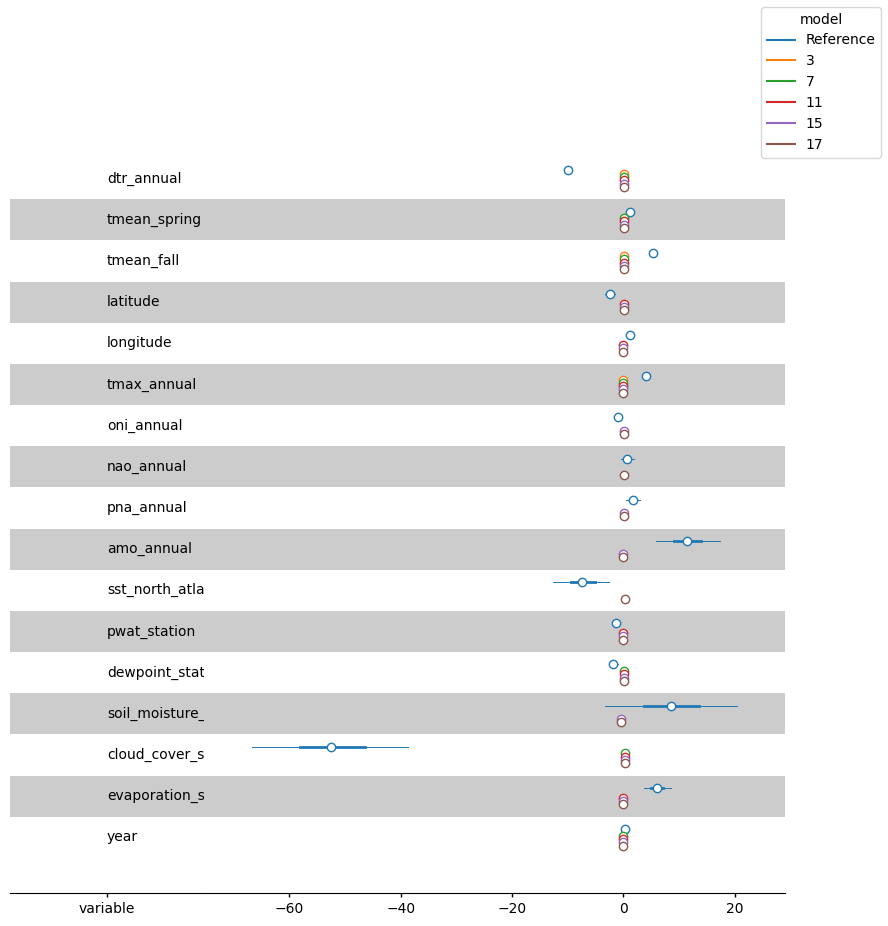

In [13]:
kpt.plot_forest(ppi, submodels = [3,7,11,15,17], include_reference = True, figure_kwargs= {"figsize": (10,10)})

### 7/8 Work

In [24]:
all_cov_str = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + dewpoint_station + soil_moisture_station + cloud_cover_station + evaporation_station + dtr_spring + sst_gulf_mexico + pwat_southeast_us + dewpoint_2m_southeast_us + soil_moisture_southeast_us + cloud_cover_southeast_us + evaporation_southeast_us'
all_cov_unstandardized_model, all_cov_unstandardized_output, resid_all_cov, r2_set_all_cov = bayesian_model_unstandardized(pa_gs, 'growing_season_length', all_cov_str)
az.summary(all_cov_unstandardized_output).head(36)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.109       31          146.21 draws/s       0:00:13    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.160       31          121.78 draws/s       0:00:16    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.136       31          123.80 draws/s       0:00:16    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.131       31          135.78 draws/s       0:00:14    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,127,70,15,240,2893,3172,1.00,1.3,0.91
dtr_annual,-9.51,0.46,-10,-8.8,2773,3077,1.00,0.0087,0.0063
tmean_spring,1.234,0.271,0.79,1.7,3514,3076,1.00,0.0046,0.0033
tmean_fall,5.758,0.278,5.3,6.2,4099,3226,1.00,0.0044,0.0032
latitude,-2.59,0.61,-3.6,-1.6,3959,3293,1.00,0.0097,0.0068
longitude,1.408,0.208,1.1,1.7,3750,3100,1.00,0.0034,0.0024
tmax_annual,3.62,0.46,2.9,4.4,2963,2923,1.00,0.0085,0.006
oni_annual,0.11,0.504,-0.68,0.92,5273,3310,1.00,0.007,0.0049
nao_annual,0.31,0.83,-1,1.6,3503,3136,1.00,0.014,0.0097
pna_annual,2.24,0.91,0.75,3.7,6093,3381,1.00,0.012,0.0085


In [29]:
all_cov_list = ['dtr_annual','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station', 'dtr_spring',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']
posteriors_dict = {}
for cov in all_cov_list:
    posterior = all_cov_unstandardized_output.posterior[cov]
    q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
    posteriors_dict[cov] = [q05, q95, q05 <= 0 <= q95]

posteriors_df = pd.DataFrame(posteriors_dict)
post_df_names = {0:'q05', 1:'q95', 2: "crosses 0"}
posteriors_df = posteriors_df.rename(index = post_df_names)
posteriors_df[['dtr_annual','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station']]

,dtr_annual,tmean_spring,tmean_fall,latitude,longitude,tmax_annual,oni_annual,nao_annual,pna_annual,amo_annual,sst_north_atlantic,pwat_station,dewpoint_station,soil_moisture_station,cloud_cover_station,evaporation_station
q05,-10.261009,0.776722,5.307368,-3.593889,1.069935,2.875595,-0.696988,-1.072851,0.716869,-2.672924,-8.869032,-1.892917,-1.912121,-10.621523,-42.826896,1.962907
q95,-8.782414,1.683437,6.211267,-1.608604,1.756219,4.372724,0.945459,1.672539,3.718654,9.554159,2.286611,-0.88598,-0.081682,14.293778,-11.907769,7.393278
crosses 0,False,False,False,False,False,False,True,True,False,True,True,False,False,True,False,False


In [30]:
posteriors_df[['dtr_spring','sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']]

,dtr_spring,sst_gulf_mexico,pwat_southeast_us,dewpoint_2m_southeast_us,soil_moisture_southeast_us,cloud_cover_southeast_us,evaporation_southeast_us
q05,-0.776803,-2.883568,1.264352,-6.32555,-1.267327,-151.03362,-18.715869
q95,0.346934,3.912656,3.038846,-2.182906,280.030441,-90.673215,-9.143546
crosses 0,True,True,False,False,True,False,False


Variables >without< 95% significance:
* ONI annual
* NAO annual
* AMO annual
* SST North Atlantic
* Station Soil Moisture
* DTR Spring
* SST Gulf of Mexico
* Southeast US Soil Moisture

Notable Coefficients with significance:
* for every degree increase in annual mean DTR, GSL decreases 9.51 days
* for every degree increase in mean Fall Temperature, GSL increases 5.758 days
* for every 10% area of sky increase in Southeast US Cloud Cover, GSL increases 12.04 days

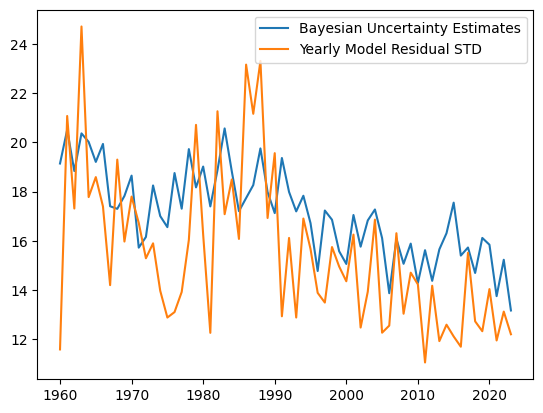

In [44]:
all_cov_gsl_list = ['year', 'growing_season_length', 'dtr_annual','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station', 'dtr_spring',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']
def remove_nulls_simple(data_subset, variables):
        # Drop rows where any of the specified variable columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=variables, ignore_index=True)
        # Subsets the cleaned dataframe back into only chosen variables
        vars_cleaned = data_subset_cleaned[variables]
        return vars_cleaned
pa_gs_cleaned = remove_nulls_simple(pa_gs, all_cov_gsl_list)

resids = pa_gs_cleaned['growing_season_length'].values - all_cov_unstandardized_model.predict(all_cov_unstandardized_output, inplace=False).posterior["mu"].mean(("chain", "draw")).values
pa_gs_cleaned['resids'] = resids

# compute predictions over chains/draws
all_cov_unstandardized_model.predict(all_cov_unstandardized_output, kind="response_params") 
# average over draws and then add to the data frame
sigma_hats = all_cov_unstandardized_output.posterior["sigma"].mean(("chain", "draw")).values  
pa_gs_cleaned["sigma_hat"] = sigma_hats
# aggregate by year
sig_by_year = pa_gs_cleaned.groupby("year")["sigma_hat"].mean()
# to get the empirical stds:
empirical_stds_yearly  = pa_gs_cleaned.groupby("year")["resids"].std()
plt.plot(sig_by_year, label = 'Bayesian Uncertainty Estimates')
plt.plot(empirical_stds_yearly, label = 'Yearly Model Residual STD')
plt.legend()
plt.show()

Analysis:
* After a period of higher Residual STD in the 1980s, it has steadily decreased in the 35 years since.
* The model estimates uncertainty to be slightly higher in the past three decades than it has been, but only slightly. It follows the shape of the Residual STD well, though not having much succeess in predicting the extremes.

Further Analysis (Considering smaller models where same graph was created in Bayesian_Modeling_wk_7_pt_2
* Models with fewer covariates (only 3) have much smaller Bayesian Uncertainty Estimates (<1) and higher Residual STD (30-40)

In [49]:
formula_dtr = bmb.Formula(f"dtr_annual ~  year",
                      f"sigma ~ year")
model_dtr = bmb.Model(formula_dtr, data=pa_gs, dropna = True)
output_dtr = model_dtr.fit(idata_kwargs={'log_likelihood':True})

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.929       3           2370.42 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           1.154       3           2290.89 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.784       3           2777.58 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.985       3           1891.44 draws/s      0:00:01    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [50]:
az.summary(output_dtr)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,36.62,1.78,34,40,5570,3340,1.00,0.024,0.018
year,-0.01254,0.00089,-0.014,-0.011,5587,3248,1.00,1.2e-05,8.8e-06
sigma_Intercept,10.3,1,8.7,12,6577,3273,1.00,0.012,0.0088
sigma_year,-0.00501,0.000504,-0.0058,-0.0042,6557,3259,1.00,6.3e-06,4.4e-06


In [56]:
dtr_posterior_yr = output_dtr.posterior['year']
dtr_posterior_sigma_yr = output_dtr.posterior['sigma_year']
dtr_yr_q05, dtr_yr_q95 = float(dtr_posterior_yr.quantile(.05)), float(dtr_posterior_yr.quantile(.95))
dtr_syr_q05, dtr_syr_q95 = float(dtr_posterior_sigma_yr.quantile(.05)), float(dtr_posterior_sigma_yr.quantile(.95))
print(f'5% Year: {dtr_yr_q05}')
print(f'95% Year: {dtr_yr_q95}')
print(f'5% Sigma_Year: {dtr_syr_q05}')
print(f'95% Sigma_Year: {dtr_syr_q95}')
print("Both DTR Trend and DTR Variance Trend are significant at 95%")

5% Year: -0.01403720431215636
95% Year: -0.011085778024937288
5% Sigma_Year: -0.005856644363799441
95% Sigma_Year: -0.004173152337790194
Both DTR Trend and DTR Variance Trend are significant at 95%
